## <span style="color: blue;">[Article Part 1: Value-Based Reinforcement Learning Transforms Intuition (Q-Learning)- The Theory of Optimizing Customer Funnels]</span>
(https://medium.com/@shukla.shankar.ravi/value-based-reinforcement-learning-transforms-intuition-q-learning-the-theory-of-optimizing-0e7594459569)

## <span style="color: blue;">[Article Part 2: Building a Smart Marketing Funnel Agent with Q-Learning and Deep Q-Networks (Ray RLlib Implementation) - The Practice]</span>
(https://medium.com/@shukla.shankar.ravi/building-a-smart-marketing-funnel-agent-with-q-learning-and-deep-q-networks-ray-rllib-14fdfff2399f)


In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="pandas")
warnings.filterwarnings("ignore", category=UserWarning)



In [2]:
# ----------------------------
# 1. Import Packages
# ----------------------------

import numpy as np
import pandas as pd
import random


import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode, iplot

import matplotlib.pyplot as plt

%config InlineBackend.figure_format = "retina"
init_notebook_mode(connected=True)

## Section 1 — Funnel Definition

In [3]:
# ----------------------------
# 1. Funnel and Actions
# ----------------------------
funnel_stages = ["Awareness", "Interest", "Consideration", "Purchase", "Retention", "Churn"]
actions = ["Do Nothing", "Small Coupon", "Medium Coupon", "Recommendation", "Email"]
state_mapping = {s: i for i, s in enumerate(funnel_stages)}


## Section 2 — Manual DQN Neural Network

In [4]:
# ----------------------------
# 2. Neural Network
# ----------------------------

class DQNNet(nn.Module):
    def __init__(self, n_states, n_actions):
        super(DQNNet, self).__init__()

        # First fully-connected layer: input = number of funnel stages (one-hot)
        self.fc1 = nn.Linear(n_states, 32)

        # Second hidden layer for richer representation
        self.fc2 = nn.Linear(32, 32)

        # Output layer predicting Q-value for each action
        self.fc3 = nn.Linear(32, n_actions)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Nonlinear activation
        x = torch.relu(self.fc2(x))
        return self.fc3(x)           # Raw Q-values (no softmax)
    
policy_net = DQNNet(len(funnel_stages), len(actions))
optimizer = optim.Adam(policy_net.parameters(), lr=0.01)
criterion = nn.MSELoss()

## Section 3 — Environment Functions (get_reward and next_state)

In [5]:

# ----------------------------
# 3. Reward and Next State
# ----------------------------
def get_reward(current_stage, action):
    # Synthetic rules defining how effective each action is at each stage.
    # e.g., coupons are helpful in Awareness and Consideration.
    if current_stage == "Awareness" and "Coupon" in action:
        return random.choice([5, 10])
    elif current_stage == "Interest" and "Medium" in action:
        return random.choice([10, 15])
    elif current_stage == "Consideration" and "Medium" in action:
        return random.choice([50, 100])
    elif "Do Nothing" in action:
        return random.choice([-2, 0])
    else:
        return random.choice([-1, 1])

def next_state(current_stage, reward):
    idx = state_mapping[current_stage]
    n = len(funnel_stages)
    
    # High rewards → jump ahead quickly in the funnel
    if reward > 50 and idx < n - 2:
        return funnel_stages[idx + 2]
    
    # Moderate rewards → advance by one stage
    elif reward > 10 and idx < n - 1:
        return funnel_stages[idx + 1]
    
    # Negative rewards → potentially drop back a stage
    elif reward < -5 and idx > 0:
        return funnel_stages[idx - 1]
    
    # Very negative → churn
    elif reward < -20:
        return funnel_stages[-1]   # churn
    
    # Otherwise stay in the same stage
    else:
        return current_stage


## Section 4 — Q-Neural Network Training

In [6]:

# ----------------------------
# 4. Helper to build Q-table from network
# ----------------------------
def build_q_table_from_network(policy_net, funnel_stages, actions):
    q_matrix = []
    for s in range(len(funnel_stages)):
        state_vec = torch.zeros(len(funnel_stages))
        state_vec[s] = 1.0
        with torch.no_grad():
            q_values = policy_net(state_vec).numpy()
        q_matrix.append(q_values)
    return np.array(q_matrix)



## Section 5 — Heatmap (Q-Value Visualization)

In [7]:
# ----------------------------
# 5. Side-by-side Heatmap
# ----------------------------
def plot_q_table_comparison(pre_table, post_table, funnel_stages, actions):
    # Desired top-to-bottom order
    stage_order = ["Awareness", "Interest", "Consideration", "Purchase", "Retention"]

    # Reverse for Plotly so that the first item is at the bottom internally
    stage_order_plotly = stage_order[::-1]
    
    pre_df = pd.DataFrame(pre_table, index=funnel_stages, columns=actions).reindex(stage_order_plotly)
    post_df = pd.DataFrame(post_table, index=funnel_stages, columns=actions).reindex(stage_order_plotly)
    
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Pre-Training Q-Values", "Post-Training Q-Values"),
        horizontal_spacing=0.15   # <<--- adds more margin between plots
    )

    # --- Pre-training heatmap ---
    fig.add_trace(
        go.Heatmap(
            z=pre_df.values,
            x=pre_df.columns,
            y=pre_df.index,
            colorscale="Blues",
            text=pre_df.round(1).astype(str),
            texttemplate="%{text}",
            showscale=False
        ),
        row=1, col=1
    )

    # --- Post-training heatmap ---
    fig.add_trace(
        go.Heatmap(
            z=post_df.values,
            x=post_df.columns,
            y=post_df.index,
            colorscale="Reds",
            text=post_df.round(1).astype(str),
            texttemplate="%{text}",
            showscale=False
        ),
        row=1, col=2
    )

    fig.update_layout(
        height=600,
        width=1000,
        title_text="Q-Value Heatmaps Before and After Training",
    )

    fig.update_xaxes(title_text="Actions", row=1, col=1)
    fig.update_yaxes(title_text="Funnel Stages", row=1, col=1)
    fig.update_xaxes(title_text="Actions", row=1, col=2)
    fig.update_yaxes(title_text="Funnel Stages", row=1, col=2)
    
    fig.show()


## Section 6 — DQN Training Loop

In [8]:

# ----------------------------
# 6. Training Loop with Q-table snapshots
# ----------------------------
num_epochs = 500         # Total number of episodes (full funnel journeys)
gamma = 0.9               # Discount factor for future rewards
epsilon_start = 1.0       # Initial exploration probability (100% random)
epsilon_min = 0.1         # Minimum exploration after decay

# Capture the Q-values BEFORE any training occurs
# This allows us to visualize how the model changes during learning.
q_table_pre = build_q_table_from_network(policy_net, funnel_stages, actions)

for epoch in range(1, num_epochs+1):
    
    # Each episode starts at the top of the funnel
    state = "Awareness"
    
    # Linear decay of epsilon across training
    # Encourages exploration early, exploitation later.
    epsilon = max(epsilon_min, epsilon_start - epoch/num_epochs)
    
    # Limit each episode to 10 decision steps
    for step in range(10):
        
        # Convert current funnel stage to one-hot input vector
        state_vec = torch.zeros(len(funnel_stages))
        state_vec[state_mapping[state]] = 1.0
        
        # ε-greedy
        # Epsilon-greedy action selection
        if random.random() < epsilon:
            action_idx = random.randint(0, len(actions)-1)
        else:
            with torch.no_grad():
                q_values = policy_net(state_vec)
            action_idx = torch.argmax(q_values).item()
        action = actions[action_idx]
        
        # Environment interaction
        reward = get_reward(state, action)     # Synthetic reward
        next_s = next_state(state, reward)     # Next funnel stage (synthetic)
        
        # Prepare next state as one-hot vector
        next_vec = torch.zeros(len(funnel_stages))
        next_vec[state_mapping[next_s]] = 1.0
        
        # Compute TD target: r + γ * max(Q_next)
        with torch.no_grad():
            max_next_q = torch.max(policy_net(next_vec))
        target = reward + gamma * max_next_q
        
        # Train (backpropagate prediction error)
        optimizer.zero_grad()
        output = policy_net(state_vec)[action_idx]
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        # Move to next state
        state = next_s



## Section 7 — Q-Value Comparison

In [9]:
# ----------------------------
# 7. Q-Value Comparison
# ----------------------------

# Capture final Q-values AFTER training
q_table_post = build_q_table_from_network(policy_net, funnel_stages, actions)

# ----------------------------
# 8. Compare Pre vs Post Training Q-tables
# ----------------------------
plot_q_table_comparison(q_table_pre, q_table_post, funnel_stages, actions)

# Section 8 — Q-Value Comparison

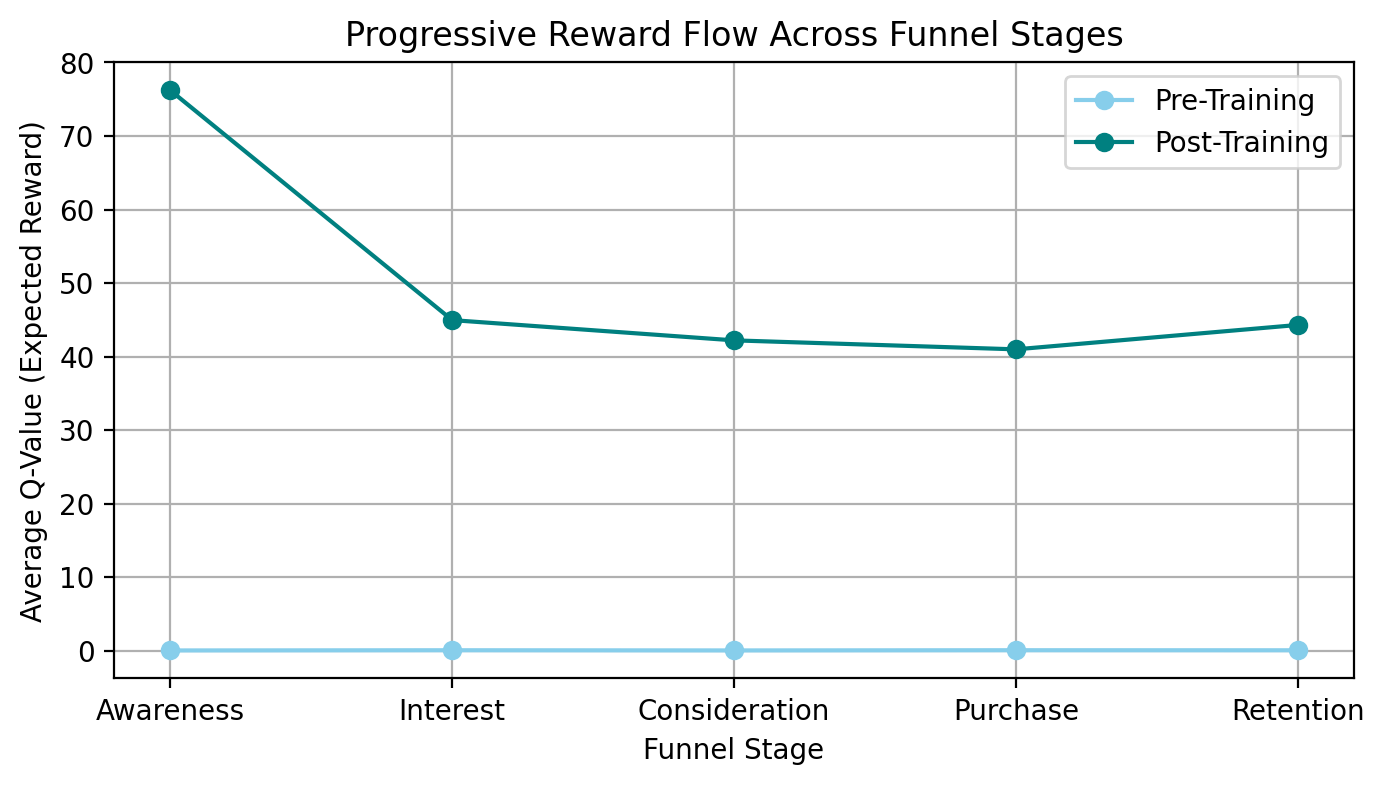

In [10]:


# -----------------------------------------------
# 8. Q-Value Comparison
# -----------------------------------------------
# Compute average action value per stage (proxy for cumulative reward)


    
avg_rewards_pre = q_table_pre[:-1].mean(axis=1)
avg_rewards_post = q_table_post[:-1].mean(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(funnel_stages[:-1], avg_rewards_pre, marker="o", color="skyblue", label="Pre-Training")
plt.plot(funnel_stages[:-1], avg_rewards_post, marker="o", color="teal", label="Post-Training")
plt.title("Progressive Reward Flow Across Funnel Stages")
plt.xlabel("Funnel Stage")
plt.ylabel("Average Q-Value (Expected Reward)")
plt.legend()
plt.grid(True)
plt.show()
